In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, ConfusionMatrixDisplay, recall_score, accuracy_score
from sklearn.metrics import  f1_score, mean_absolute_error, auc, roc_curve, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [2]:
df = pd.read_csv("indian_liver_patient.csv")
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [4]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [6]:
df['Albumin_and_Globulin_Ratio'].mean()
df = df.fillna(0.94)

In [7]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [8]:
label_encode = LabelEncoder()
labels = label_encode.fit_transform(df['Gender'])
df['Gender']= labels
df['Gender'].value_counts()

Gender
1    441
0    142
Name: count, dtype: int64

In [9]:
# separate independent & dependent variables
X = df.iloc[:,0:14]  #independent columns
y = df.iloc[:,-1]    #target column i.e price range

# apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(11,'Score'))  #print 10 best features

                         Specs         Score
6   Aspartate_Aminotransferase  10203.328978
5     Alamine_Aminotransferase   6421.919946
4         Alkaline_Phosphotase   4039.855702
2              Total_Bilirubin    329.873827
3             Direct_Bilirubin    187.005784
10                     Dataset     92.629333
0                          Age     64.315174
8                      Albumin      3.053371
9   Albumin_and_Globulin_Ratio      1.641033
1                       Gender      0.964518
7               Total_Protiens      0.129627


In [10]:
featureScores = featureScores.sort_values(by='Score', ascending=False)
featureScores

,Specs,Score
6,Aspartate_Aminotransferase,10203.328978
5,Alamine_Aminotransferase,6421.919946
4,Alkaline_Phosphotase,4039.855702
2,Total_Bilirubin,329.873827
3,Direct_Bilirubin,187.005784
10,Dataset,92.629333
0,Age,64.315174
8,Albumin,3.053371
9,Albumin_and_Globulin_Ratio,1.641033
1,Gender,0.964518


In [11]:
features_list = featureScores["Specs"].tolist()[:10]
features_list

['Aspartate_Aminotransferase',
 'Alamine_Aminotransferase',
 'Alkaline_Phosphotase',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Dataset',
 'Age',
 'Albumin',
 'Albumin_and_Globulin_Ratio',
 'Gender']

In [12]:
df = df[['Aspartate_Aminotransferase',
 'Alamine_Aminotransferase',
 'Alkaline_Phosphotase',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Dataset',
 'Age',
 'Albumin',
 'Albumin_and_Globulin_Ratio',
 'Gender']]

,Aspartate_Aminotransferase,Alamine_Aminotransferase,Alkaline_Phosphotase,Total_Bilirubin,Direct_Bilirubin,Dataset,Age,Albumin,Albumin_and_Globulin_Ratio,Gender
77,127,95,1620,0.6,0.1,1,68,2.1,0.80,0
115,64,88,1580,7.3,3.6,2,50,2.3,0.60,1
116,149,74,1630,0.7,0.1,1,48,2.0,0.60,1
128,83,61,1896,1.7,0.8,1,58,3.9,0.95,0
233,89,48,2110,2.0,1.4,1,33,3.0,0.90,1
429,141,102,1750,1.9,0.7,1,73,2.0,0.50,1
447,511,425,1550,23.3,12.8,1,45,3.5,0.80,0


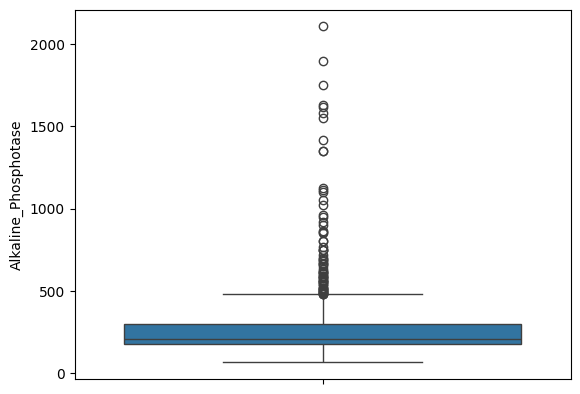

In [13]:
sns.boxplot(df.Alkaline_Phosphotase)
outliers = df[(df['Alkaline_Phosphotase'] > 1500)] 
outliers

<Axes: ylabel='Alkaline_Phosphotase'>

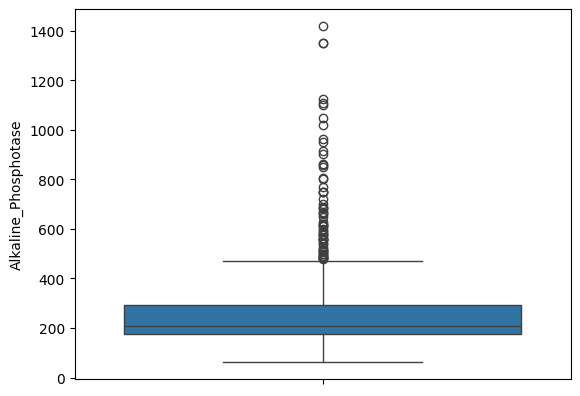

In [14]:
df = df.drop(df[df.Alkaline_Phosphotase > 1500].index)
sns.boxplot(df.Alkaline_Phosphotase)

,Aspartate_Aminotransferase,Alamine_Aminotransferase,Alkaline_Phosphotase,Total_Bilirubin,Direct_Bilirubin,Dataset,Age,Albumin,Albumin_and_Globulin_Ratio,Gender
117,2946,2000,194,12.7,6.2,1,32,3.3,1.3,1
118,1600,1350,280,15.9,7.0,1,32,2.8,1.0,1
135,4929,1250,1110,11.3,5.6,1,66,2.4,0.5,1


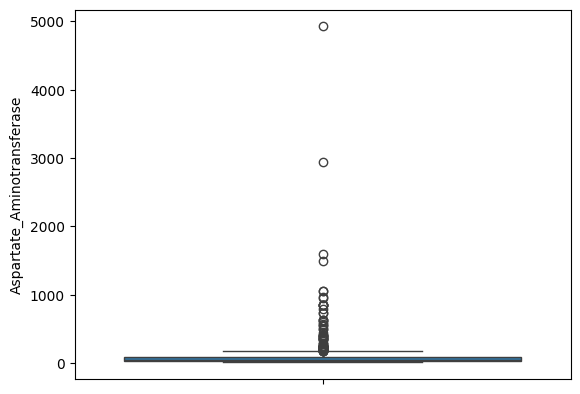

In [15]:
sns.boxplot(df.Aspartate_Aminotransferase)
outliers = df[(df['Aspartate_Aminotransferase'] > 1500)] 
outliers

<Axes: ylabel='Aspartate_Aminotransferase'>

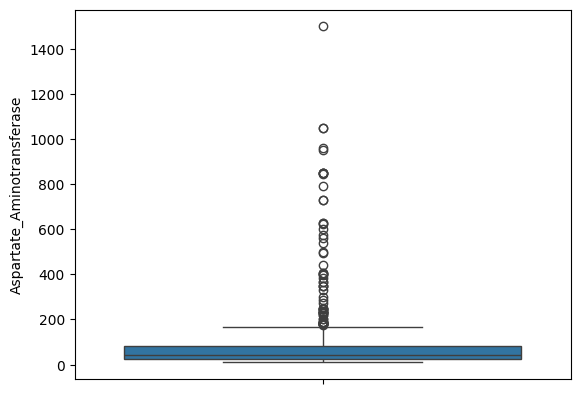

In [16]:
df = df.drop(df[df.Aspartate_Aminotransferase > 1500].index)
sns.boxplot(df.Aspartate_Aminotransferase)

,Aspartate_Aminotransferase,Alamine_Aminotransferase,Alkaline_Phosphotase,Total_Bilirubin,Direct_Bilirubin,Dataset,Age,Albumin,Albumin_and_Globulin_Ratio,Gender
27,850,1680,240,6.2,3.0,1,34,4.0,1.2,1
47,960,1630,230,1.1,0.3,1,40,2.8,1.3,1


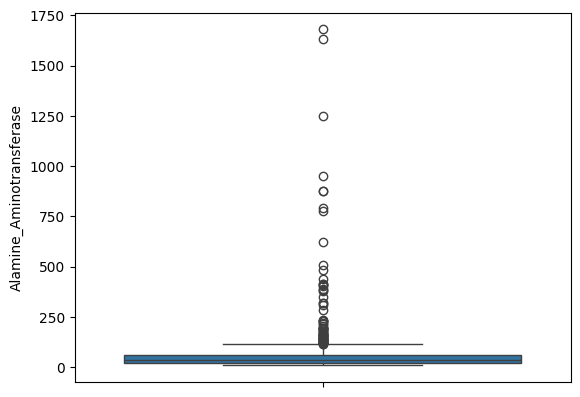

In [17]:
sns.boxplot(df.Alamine_Aminotransferase)
outliers = df[(df['Alamine_Aminotransferase'] > 1500)] 
outliers

<Axes: ylabel='Alamine_Aminotransferase'>

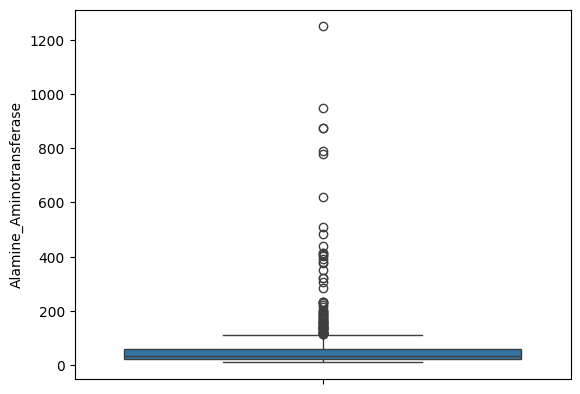

In [18]:
df = df.drop(df[df.Alamine_Aminotransferase > 1500].index)
sns.boxplot(df.Alamine_Aminotransferase)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 571 entries, 0 to 582
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Aspartate_Aminotransferase  571 non-null    int64  
 1   Alamine_Aminotransferase    571 non-null    int64  
 2   Alkaline_Phosphotase        571 non-null    int64  
 3   Total_Bilirubin             571 non-null    float64
 4   Direct_Bilirubin            571 non-null    float64
 5   Dataset                     571 non-null    int64  
 6   Age                         571 non-null    int64  
 7   Albumin                     571 non-null    float64
 8   Albumin_and_Globulin_Ratio  571 non-null    float64
 9   Gender                      571 non-null    int32  
dtypes: float64(4), int32(1), int64(5)
memory usage: 46.8 KB


In [20]:
scaler = MinMaxScaler(feature_range=(0,1)) 

#assign scaler to column:
filtered_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
filtered_data.describe()

,Aspartate_Aminotransferase,Alamine_Aminotransferase,Alkaline_Phosphotase,Total_Bilirubin,Direct_Bilirubin,Dataset,Age,Albumin,Albumin_and_Globulin_Ratio,Gender
count,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000
mean,0.053972,0.045962,0.153892,0.037799,0.068596,0.290718,0.472936,0.488731,0.259447,0.756567
std,0.103057,0.092885,0.133238,0.082664,0.141414,0.454492,0.188592,0.173155,0.127632,0.429530
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.010067,0.010484,0.082535,0.005362,0.005102,0.000000,0.337209,0.369565,0.160000,1.000000
50%,0.020805,0.019355,0.105380,0.008043,0.010204,0.000000,0.476744,0.478261,0.256000,1.000000
75%,0.048658,0.039516,0.169492,0.028820,0.056122,1.000000,0.622093,0.630435,0.320000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
filtered_data.Dataset.value_counts()

Dataset
0.0    405
1.0    166
Name: count, dtype: int64

In [22]:
# Shuffle df
shuffled_df = filtered_data.sample(frac=1,random_state=4, replace = True)

# Put all the fraud class in a separate dataset.
CHD_df = shuffled_df.loc[shuffled_df['Dataset'] == 1]

#Randomly select 492 observations from the non-fraud (majority class)
non_CHD_df = shuffled_df.loc[shuffled_df['Dataset'] == 0].sample(n=161,random_state=42, replace = True)

# Concatenate both dataframes again
normalized_df = pd.concat([CHD_df, non_CHD_df])

# check new class counts
normalized_df.Dataset.value_counts()


Dataset
0.0    161
1.0    149
Name: count, dtype: int64

In [23]:
P = normalized_df.Dataset
X = normalized_df.drop(['Dataset'], axis = 1)

In [24]:
P.value_counts()

Dataset
0.0    161
1.0    149
Name: count, dtype: int64

In [25]:
x_train, x_test, y_train, y_test = train_test_split(X,P,test_size  = 0.25, random_state = 42)

In [26]:
# Define a result table as a DataFrame
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y = y_test.values

In [27]:
#Logistic Regression

Confusion Matrix (Testing Data):


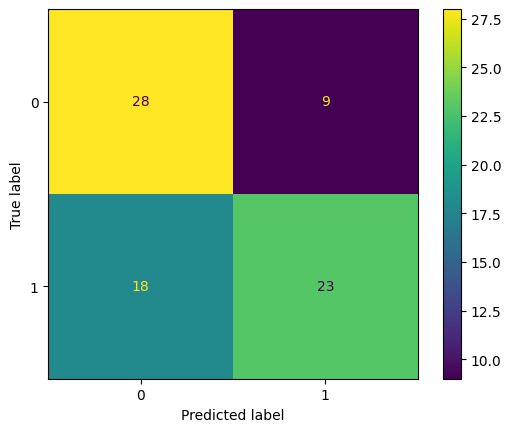

Accuracy Test :  65.38461538461539
Precision Score:  71.875
Recall Score :  56.09756097560976
F1 score :  63.01369863013699
Mean absolute error : 34.61538461538461
AUC score :  65.88661832564271


C:\Users\Hp\AppData\Local\Temp\ipykernel_18900\340699862.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"LogisticRegression",


In [28]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
test_res = lr.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

######################################

yproba = lr.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"LogisticRegression",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [29]:
#random forest classifier

Confusion Matrix (Testing Data):


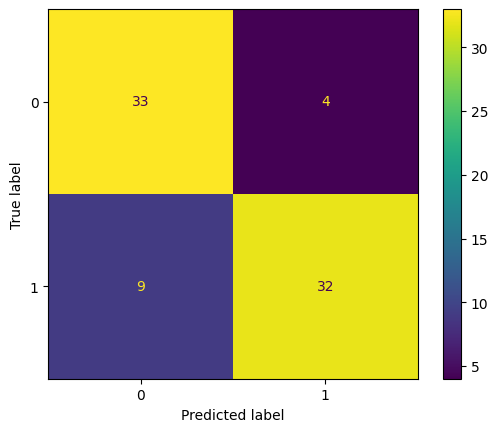

Accuracy Test :  83.33333333333334
Precision Score:  88.88888888888889
Recall Score :  78.04878048780488
F1 score :  83.11688311688312
Mean absolute error : 16.666666666666664
AUC score :  83.61898483849703


In [30]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
test_res = rf.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##################################
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"RandomForestClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)


In [31]:
#DTC

Confusion Matrix (Testing Data):


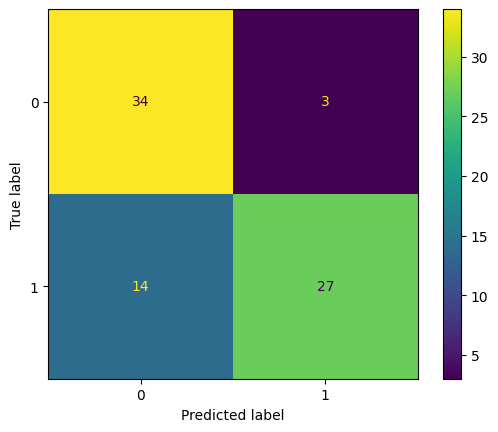

Accuracy Test :  78.2051282051282
Precision Score:  90.0
Recall Score :  65.85365853658537
F1 score :  76.05633802816902
Mean absolute error : 21.794871794871796
AUC score :  78.87277521423863


In [32]:
dtc = DecisionTreeClassifier(splitter = 'random')
dtc.fit(x_train,y_train)
test_res = dtc.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


##############################################

yproba = dtc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"DecisionTreeClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

Confusion Matrix (Testing Data):


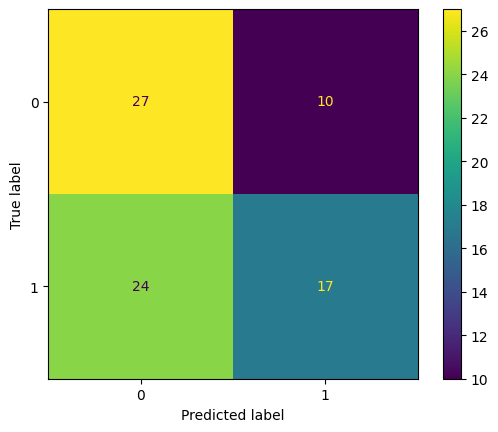

Accuracy Test :  56.41025641025641
Precision Score:  62.96296296296296
Recall Score :  41.46341463414634
F1 score :  50.0
Mean absolute error : 43.58974358974359
AUC score :  57.21819380355966


In [33]:
#SVC
svc = SVC(kernel = 'linear', probability = True)
svc.fit(x_train,y_train)
test_res = svc.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##################################

yproba = svc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"SVC",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

Confusion Matrix (Testing Data):


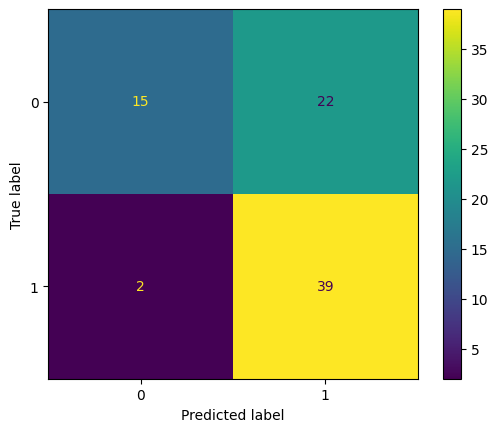

Accuracy Test :  69.23076923076923
Precision Score:  63.934426229508205
Recall Score :  95.1219512195122
F1 score :  76.47058823529413
Mean absolute error : 30.76923076923077
AUC score :  67.83124588002636


In [34]:
#Gaussian
gnb = GaussianNB()
gnb.fit(x_train, y_train)
test_res = gnb.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


##########################################

yproba = gnb.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"NaiveBayes",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

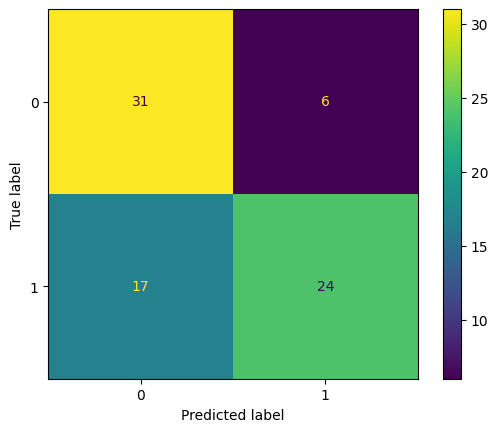

Accuracy Test :  70.51282051282051
Precision Score:  80.0
Recall Score :  58.536585365853654
F1 score :  67.6056338028169
Mean absolute error : 29.48717948717949
AUC score :  71.16018457481871


In [35]:
#KN Classifier 
kn = KNeighborsClassifier(n_neighbors = 10)
kn.fit(x_train, y_train)

test_res = kn.predict(x_test)

#Confusion Matrix 

confusion_matrix_test = confusion_matrix(y_test, test_res)

obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###
fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

#####################################################


yproba = kn.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"KNeighborsClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)
result_table.set_index('classifiers', inplace=True)

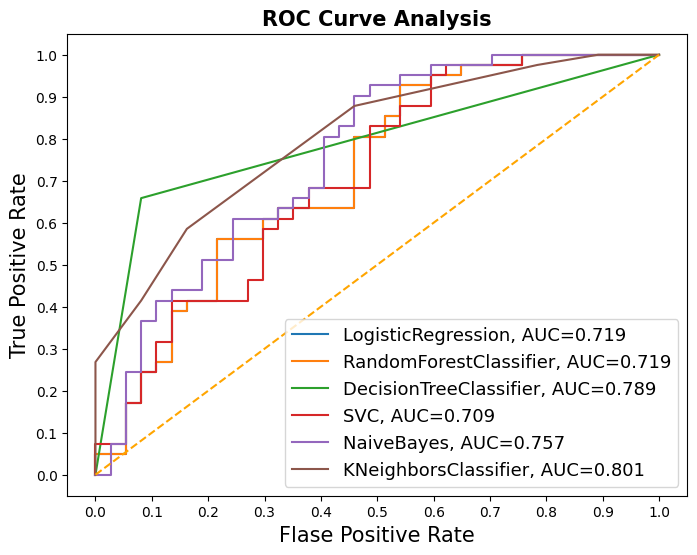

In [36]:
fig = plt.figure(figsize=(8,6))

for i in result_table.index:
    plt.plot(result_table.loc[i]['fpr'], 
             result_table.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, result_table.loc[i]['auc']))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')

plt.show()